In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv('heart_disease.csv')
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(999, 13)

In [4]:
df.size

12987

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    float64
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    float64
 4   chol      908 non-null    float64
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    float64
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB


In [6]:
df.isnull().sum()

age          91
sex          91
cp           91
trestbps     91
chol         91
fbs          91
restecg      91
thalch       91
exang        91
oldpeak     153
slope        91
thal         91
num          91
dtype: int64

In [7]:
for col in df.select_dtypes(include=['int','float']).columns:
    print(col,end=",")

age,trestbps,chol,thalch,oldpeak,num,

In [8]:
for col in df.select_dtypes(include=['object']).columns:
    print(col,end=",")

sex,cp,fbs,restecg,exang,slope,thal,

In [9]:
from sklearn.impute import SimpleImputer
cols=['age','trestbps','chol','thalch','oldpeak','num']
imputer=SimpleImputer(strategy='median')
df[cols]=imputer.fit_transform(df[cols])

In [10]:
from sklearn.impute import SimpleImputer
cols=['sex','cp','fbs','restecg','exang','slope','thal']
imputer=SimpleImputer(strategy='most_frequent')
df[cols]=imputer.fit_transform(df[cols])

In [11]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(91)

In [13]:
df=df.drop_duplicates()

In [14]:
df.duplicated().sum()

np.int64(0)

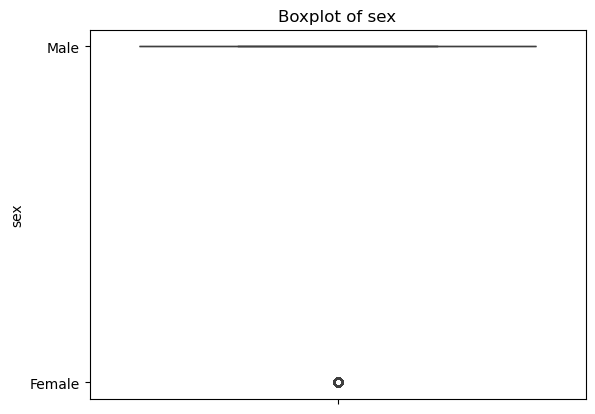

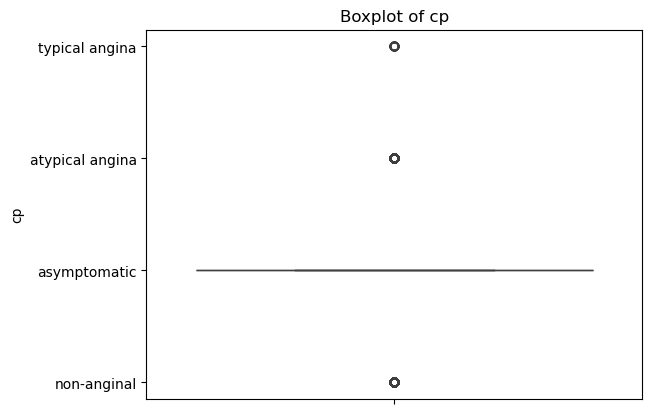

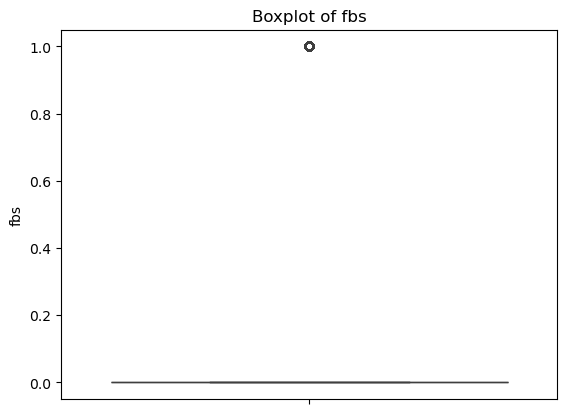

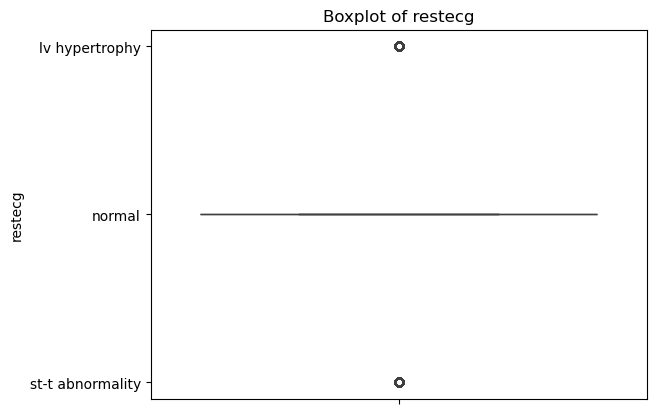

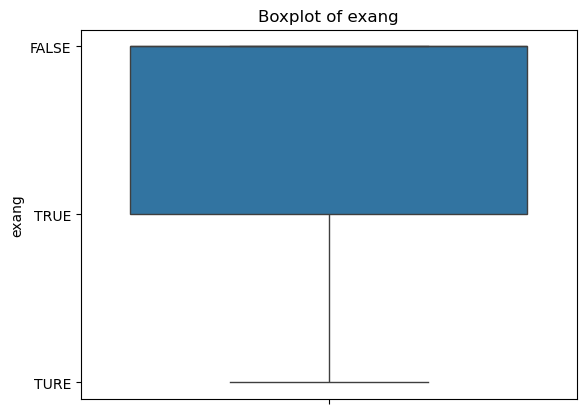

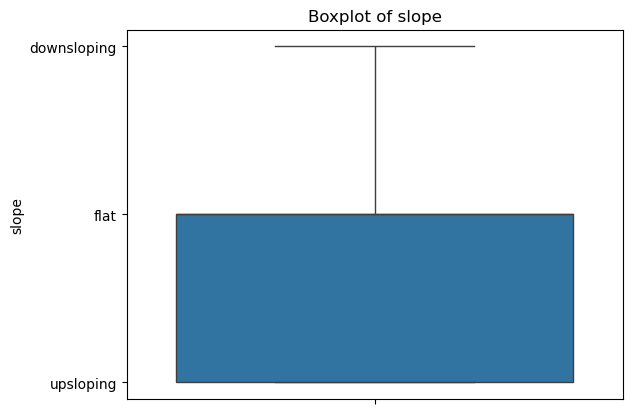

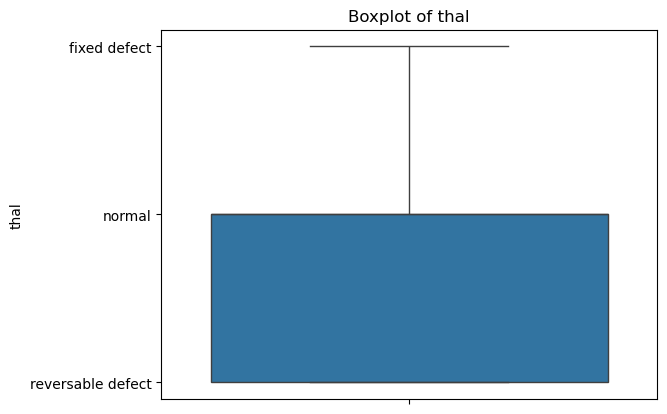

In [15]:
for col in df.select_dtypes(include=['object']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [16]:
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr
    df=df[(df[i]>=lower) & (df[i]<=upper)]

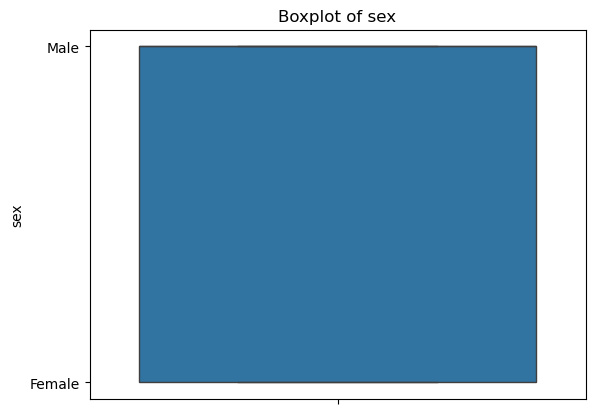

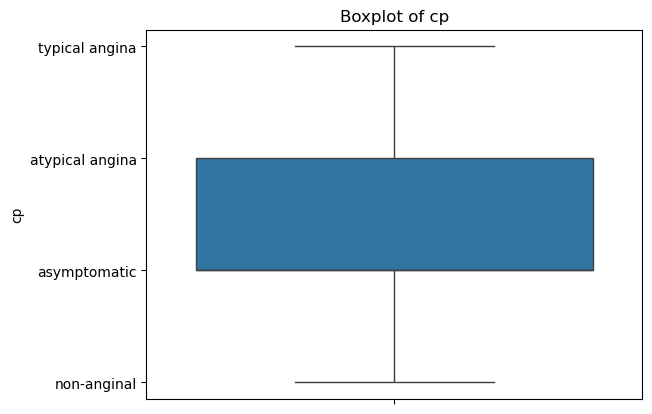

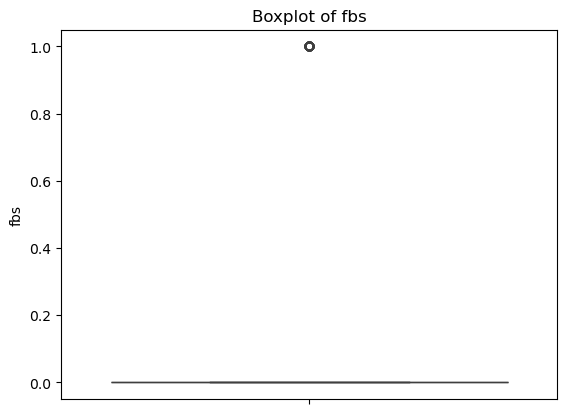

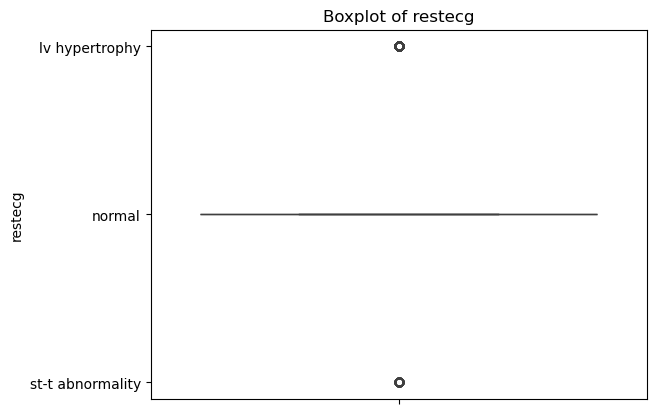

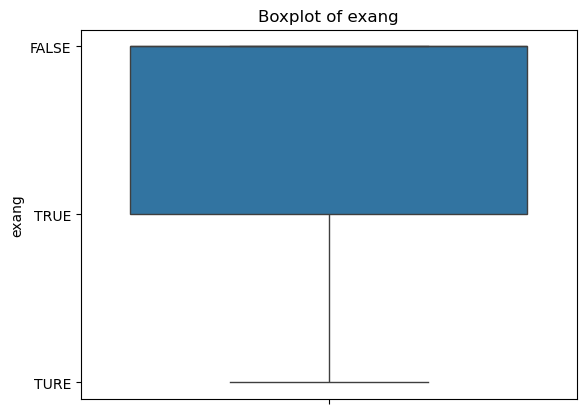

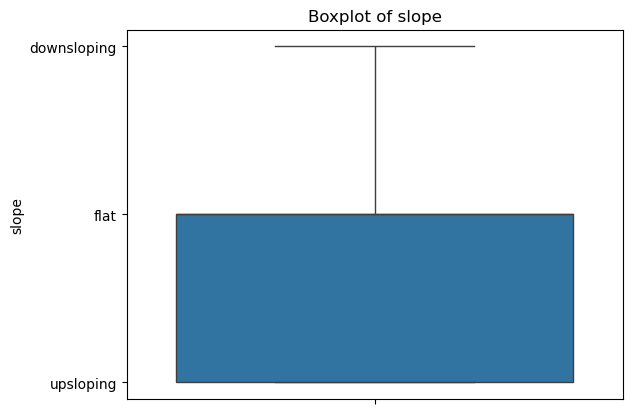

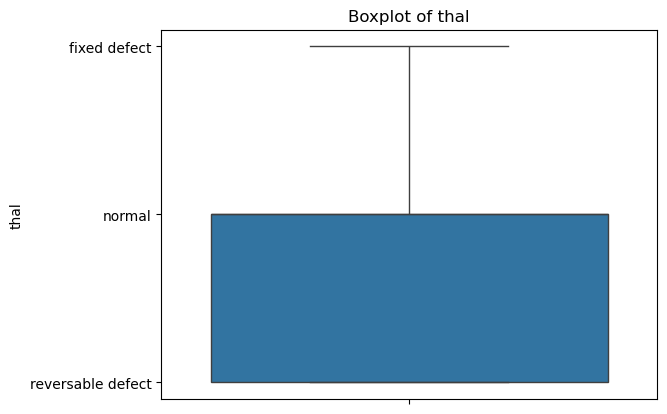

In [17]:
for col in df.select_dtypes(include=['object']).columns:
    sns.boxplot(df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [18]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
762,72.0,Male,asymptomatic,160.0,213.0,True,lv hypertrophy,130.0,FALSE,1.5,upsloping,fixed defect,2.0
764,58.0,Male,non-anginal,150.0,219.0,False,st-t abnormality,118.0,TRUE,0.0,downsloping,reversable defect,2.0
767,58.0,Male,non-anginal,158.0,232.0,False,st-t abnormality,138.0,TURE,0.5,downsloping,fixed defect,2.0
772,64.0,Male,asymptomatic,146.0,244.0,True,st-t abnormality,97.0,TURE,0.5,upsloping,reversable defect,2.0


In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    df[col]=le.fit_transform(df[[col]])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,1,3,145.0,233.0,1,0,150.0,0,2.3,0,0,0.0
1,41.0,1,1,135.0,203.0,0,1,132.0,0,0.0,1,0,0.0
2,57.0,1,0,140.0,192.0,0,1,148.0,0,0.4,1,0,0.0
3,52.0,1,3,118.0,186.0,0,0,190.0,0,0.0,1,0,0.0
4,57.0,1,0,110.0,201.0,0,1,126.0,1,1.5,1,0,0.0


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 617 entries, 0 to 908
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       617 non-null    float64
 1   sex       617 non-null    int64  
 2   cp        617 non-null    int64  
 3   trestbps  617 non-null    float64
 4   chol      617 non-null    float64
 5   fbs       617 non-null    int64  
 6   restecg   617 non-null    int64  
 7   thalch    617 non-null    float64
 8   exang     617 non-null    int64  
 9   oldpeak   617 non-null    float64
 10  slope     617 non-null    int64  
 11  thal      617 non-null    int64  
 12  num       617 non-null    float64
dtypes: float64(6), int64(7)
memory usage: 67.5 KB


In [21]:
x=df.drop(columns=['num'])
y=df['num']

In [22]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
for col in x.columns:
    df[col]=sc.fit_transform(df[[col]])
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1.205508,0.604189,2.210411,0.742463,-0.196405,2.358777,-1.555083,0.357721,-0.699727,1.742190,-1.730181,-1.498484,0.0
1,-1.280979,0.604189,0.118657,0.168259,-0.782390,-0.423948,0.093519,-0.360048,-0.699727,-0.812938,-0.287584,-1.498484,0.0
2,0.527376,0.604189,-0.927220,0.455361,-0.997252,-0.423948,0.093519,0.277969,-0.699727,-0.368568,-0.287584,-1.498484,0.0
3,-0.037735,0.604189,2.210411,-0.807887,-1.114449,-0.423948,-1.555083,1.952765,-0.699727,-0.812938,-0.287584,-1.498484,0.0
4,0.527376,0.604189,-0.927220,-1.267251,-0.821456,-0.423948,0.093519,-0.599305,1.145280,0.853450,-0.287584,-1.498484,0.0


In [27]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=50)

In [28]:
from sklearn.tree import DecisionTreeClassifier
dc=DecisionTreeClassifier()
dc.fit(x_train,y_train)
pred_train=dc.predict(x_train)
pred_test=dc.predict(x_test)
from sklearn.metrics import *
print("Accuracy score is:",accuracy_score(y_train,pred_train))
print("Accuracy score is:",accuracy_score(y_test,pred_test))

Accuracy score is: 1.0
Accuracy score is: 0.6370967741935484


In [33]:
from sklearn.metrics import *
print("Accuracy Score is:",accuracy_score(y_test,pred_test))
print("Precision Score is:",precision_score(y_test,pred_test,average='weighted'))
print("Recall Score is:",recall_score(y_test,pred_test,average='weighted'))
print("f1 score is:",f1_score(y_test,pred_test,average='weighted'))

Accuracy Score is: 0.6370967741935484
Precision Score is: 0.633404950674817
Recall Score is: 0.6370967741935484
f1 score is: 0.6349654377880185


In [42]:
sigmoid=dc.predict_proba(x_test)

In [43]:
from sklearn.metrics import roc_auc_score,roc_curve
auc_score=roc_auc_score(y_test,sigmoid,multi_class='ovr')
print("roc_auc score is:",auc_score)

roc_auc score is: 0.661166508998853


In [45]:
from sklearn.model_selection import GridSearchCV
params={'criterion':['gini','entropy'],'splitter':['best','random'],'max_depth':range(1,7)}
grid_search=GridSearchCV(estimator=dc,param_grid=params,cv=5)
grid_search.fit(x_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': range(1, 7), 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [46]:
grid_search.best_score_,grid_search.best_params_

(np.float64(0.6976293547722119),
 {'criterion': 'gini', 'max_depth': 2, 'splitter': 'random'})

In [47]:
from sklearn.tree import DecisionTreeClassifier
DT=DecisionTreeClassifier(criterion='gini',max_depth=2,splitter='random')
dc.fit(x_train,y_train)
pred_train=dc.predict(x_train)
pred_test=dc.predict(x_test)
from sklearn.metrics import accuracy_score
print("Train Score is:",accuracy_score(y_train,pred_train))
print("Test Score is:",accuracy_score(y_test,pred_test))

Train Score is: 1.0
Test Score is: 0.7096774193548387


In [48]:
from sklearn.metrics import *
print("Accuracy Score is:",accuracy_score(y_test,pred_test))
print("Precision Score is:",precision_score(y_test,pred_test,average='weighted'))
print("Recall Score is:",recall_score(y_test,pred_test,average='weighted'))
print("f1 score is:",f1_score(y_test,pred_test,average='weighted'))

Accuracy Score is: 0.7096774193548387
Precision Score is: 0.6974520244893759
Recall Score is: 0.7096774193548387
f1 score is: 0.6991254713028907


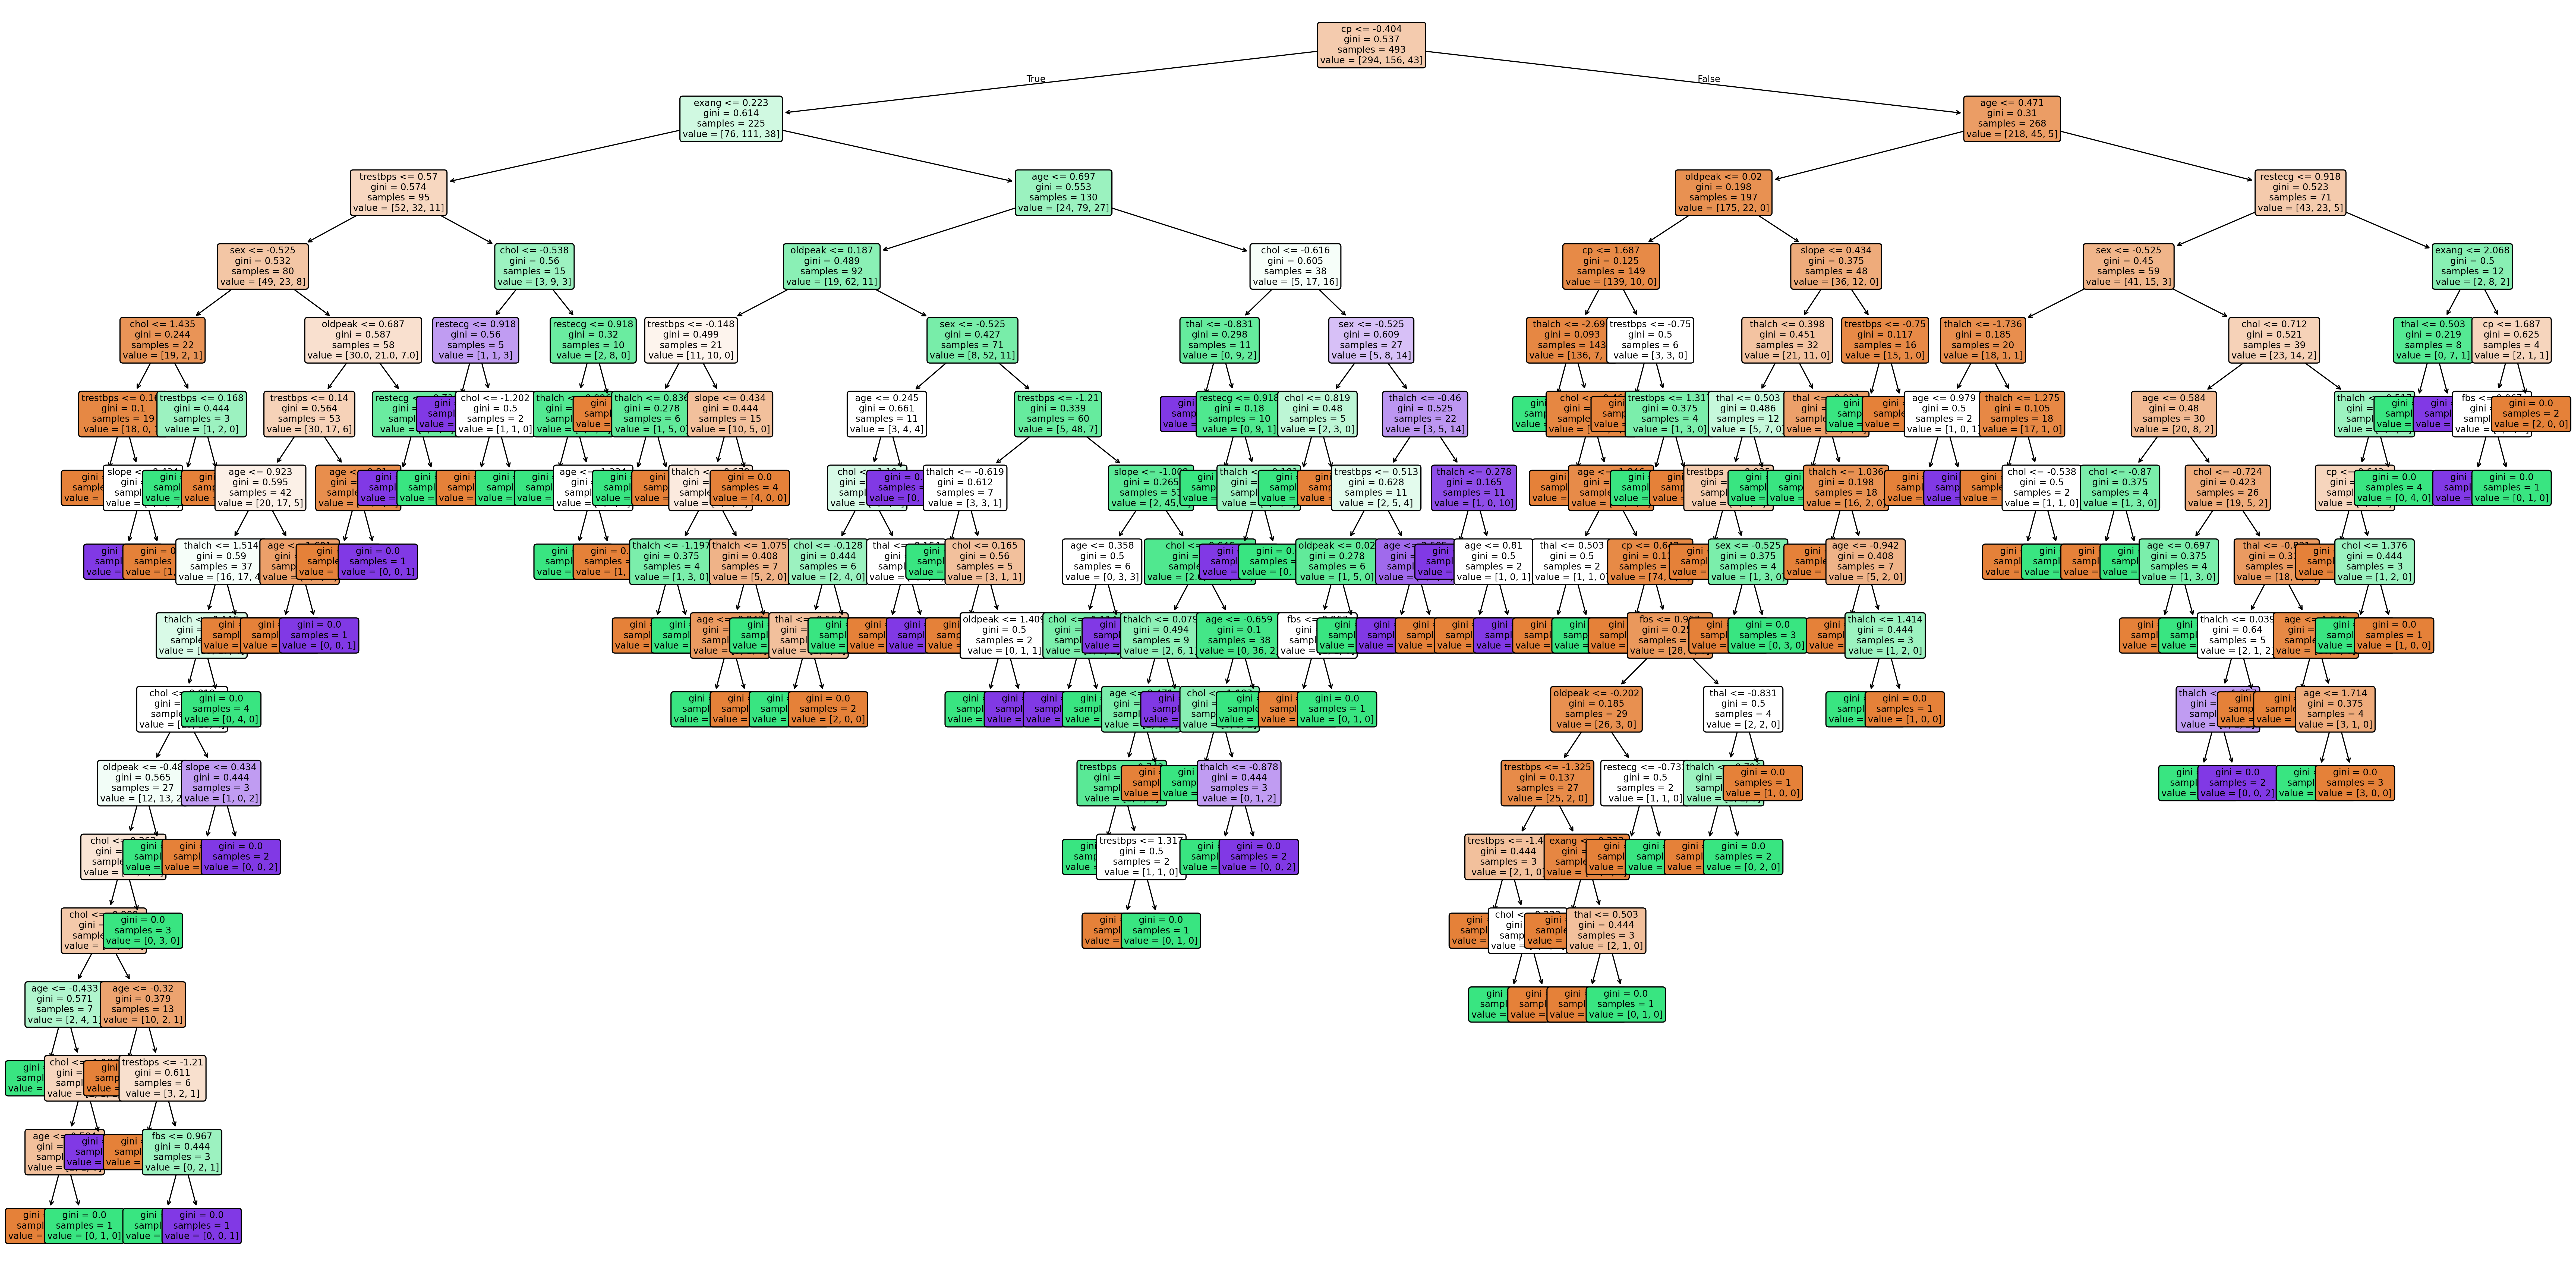

In [50]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(40, 20), dpi=300)
plot_tree(
    dc,
    filled=True,
    rounded=True,
    fontsize=8,
    feature_names=x.columns
)
plt.show()

1. Common Hyperparameters of Decision Tree Models:
1.Max_depth: Controls the maximum depth of the tree; lower values reduce overfitting.
2.Min_samples_split: Minimum samples needed to split a node.
3.Min_samples_leaf: Minimum samples required in a leaf node.
4.Criterion: Measures the quality of a split, such as Gini or Entropy.
5.Max_features: Controls the number of features considered for splitting.
6.Max_leaf_nodes: Limits the number of leaf nodes.
7.Hence,These hyperparameters control the tree's complexity and help balance underfitting and overfitting.

2. Label Encoding vs One-Hot Encoding
A.Label Encoding converts categories into numerical values such as 0, 1, 2, etc.
1.Example: Red = 0, Blue = 1, Green = 2.
2.It uses only one column, so it is memory efficient.
3.However, the numbers may suggest an unwanted order between categories.
B.One-Hot Encoding creates a separate binary column for each category.
1.Example: Red = [1,0,0], Blue = [0,1,0], Green = [0,0,1].
2.It does not imply any order between categories.
3.However, it can create many columns when there are many categories.
4.Summary: Label encoding is compact, while one-hot encoding is generally better for nominal (unordered) categories.